<h1 align="center"> DATA PROCESSING - DATA ENCODING</h1>

In [1]:
import pandas as pd
# preprocessing is a submodule and LabelEncoder 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
# (Or) in one line 
# from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler

# 06-10-2026
import seaborn as sns
import numpy as np


In [3]:
# 06-10-2026
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_excel(r"C:\Users\ELCOT\Desktop\JananiMurugan\Machine_Learning\Dataset\ML_data.xlsx")
df

,Student_ID,Department,Attendance,Internal_Marks,Study_Hours,Backlogs,Gender,Final_Result
0,101,CSE,85,78.0,12,0,Female,Pass
1,102,IT,62,45.0,5,2,Male,Fail
2,103,CSE,91,88.0,15,0,Female,Pass
3,104,ECE,74,NaN,8,1,Male,Pass
4,105,IT,55,39.0,4,3,Female,Fail


In [3]:
# sample() selects random rows from the DataFrame.
df.sample(3)

,Student_ID,Department,Attendance,Internal_Marks,Study_Hours,Backlogs,Gender,Final_Result
1,102,IT,62,45.0,5,2,Male,Fail
3,104,ECE,74,NaN,8,1,Male,Pass
0,101,CSE,85,78.0,12,0,Female,Pass


In [4]:
# head() selects the first rows of the DataFrame.
df.head(4)

,Student_ID,Department,Attendance,Internal_Marks,Study_Hours,Backlogs,Gender,Final_Result
0,101,CSE,85,78.0,12,0,Female,Pass
1,102,IT,62,45.0,5,2,Male,Fail
2,103,CSE,91,88.0,15,0,Female,Pass
3,104,ECE,74,NaN,8,1,Male,Pass


## FEATURES

In [5]:
# 0-> means rows and 1 -> means columns
# here i  want to remove the empty value so  remove that column
X=df.drop("Final_Result",axis=1)
X

,Student_ID,Department,Attendance,Internal_Marks,Study_Hours,Backlogs,Gender
0,101,CSE,85,78.0,12,0,Female
1,102,IT,62,45.0,5,2,Male
2,103,CSE,91,88.0,15,0,Female
3,104,ECE,74,NaN,8,1,Male
4,105,IT,55,39.0,4,3,Female


### TARGET

In [6]:
y=df["Final_Result"]
y

0    Pass
1    Fail
2    Pass
3    Pass
4    Fail
Name: Final_Result, dtype: str

In [7]:
# to find whether it has a null values in df 
df.isnull()

,Student_ID,Department,Attendance,Internal_Marks,Study_Hours,Backlogs,Gender,Final_Result
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False


In [8]:
# to count how many null values(true_values) there
df.isnull().sum()

Student_ID        0
Department        0
Attendance        0
Internal_Marks    1
Study_Hours       0
Backlogs          0
Gender            0
Final_Result      0
dtype: int64

# Imputation
### (Imputation means filling the missing values)
## Mean Imputation

In [9]:
# to replace the null values with value 
# I want to replace the values using mean..so i took internal marks column . 
df["Internal_Marks"]=df["Internal_Marks"].fillna(df['Internal_Marks'].mean())
df["Internal_Marks"]


0    78.0
1    45.0
2    88.0
3    62.5
4    39.0
Name: Internal_Marks, dtype: float64

## Median Imputation

In [10]:
# I want to replace the values using mean..so i took internal marks column . 
df["Internal_Marks"]=df["Internal_Marks"].fillna(df['Internal_Marks'].median())
df["Internal_Marks"]

0    78.0
1    45.0
2    88.0
3    62.5
4    39.0
Name: Internal_Marks, dtype: float64

## LABEL_ENCODING
## (Is better in binary categorical column)
### Use in Ordinal_category

In [11]:
#  to creat an object of LabelEncoder class
encoder=LabelEncoder()

##### Encode

In [12]:
# Ordered → Label/Ordinal Encoding
df["Gender_encoded"]=encoder.fit_transform(df["Gender"])

In [1]:
# To assign 0 -> for female and 1-> for men...in ascending order /  (Female , men)
df[["Gender","Gender_encoded"]]

NameError: name 'df' is not defined

In [14]:
df["Department_encoded"]=encoder.fit_transform(df["Department"])

In [15]:
# to  sort them using ascending / alphabetic order
df[["Department","Department_encoded"]]

,Department,Department_encoded
0,CSE,0
1,IT,2
2,CSE,0
3,ECE,1
4,IT,2


## ONE_HOT ENCODING 
### Used for Nominal_category in pandas

In [15]:
# Unordered → One-Hot Encoding
pd.get_dummies(df,columns=["Department"])

,Student_ID,Attendance,Internal_Marks,Study_Hours,Backlogs,Gender,Final_Result,Gender_encoded,Department_encoded,Department_CSE,Department_ECE,Department_IT
0,101,85,78.0,12,0,Female,Pass,0,0,True,False,False
1,102,62,45.0,5,2,Male,Fail,1,2,False,False,True
2,103,91,88.0,15,0,Female,Pass,0,0,True,False,False
3,104,74,62.5,8,1,Male,Pass,1,1,False,True,False
4,105,55,39.0,4,3,Female,Fail,0,2,False,False,True


## FEATURE SCALING
### Feature Scaling = make different numerical features comparable in size.

### NORMALIZATION

##### Min & Max Scaling

In [16]:
# to scale - study hours
scaler=MinMaxScaler()
df["Study_Hours_Scaled"]=scaler.fit_transform(df[["Study_Hours"]])

In [17]:
# to store the above value
df[["Study_Hours","Study_Hours_Scaled"]]

,Study_Hours,Study_Hours_Scaled
0,12,0.727273
1,5,0.090909
2,15,1.000000
3,8,0.363636
4,4,0.000000


## STANDARDIZATION
##### Standardization → mean 0, SD 1

In [18]:
std_scaler=StandardScaler()
df["Study_Hours_std_scaled"]=std_scaler.fit_transform(df[['Study_Hours']])

In [19]:
df[["Study_Hours","Study_Hours_std_scaled"]]

,Study_Hours,Study_Hours_std_scaled
0,12,0.768025
1,5,-0.912029
2,15,1.488048
3,8,-0.192006
4,4,-1.152037


In [ ]:
# Finds the median (middle value) of the Study_Hours_std_scaled column.
df["Study_Hours_std_scaled"].median()

np.float64(-0.1920061442949279)

In [ ]:
# Finds the average (mean) value of the Study_Hours_std_scaled column.
df["Study_Hours_std_scaled"].mean()

np.float64(-1.7763568394002506e-16)

##### 06-10-2026
##### To find outliers using Boxplot

Study_Hours

4
5
6
7
8
50

<Axes: >

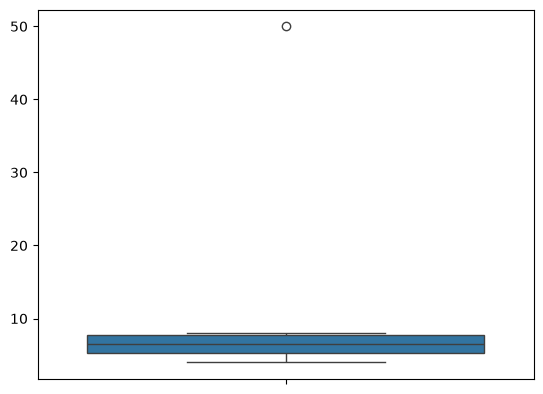

In [5]:
# To find the outliers of the following value
df=[4,5,6,7,8,50]
sns.boxplot(df)

In [6]:
#  For salary
# to find skewness 
# [ 20000 22000 25000 30000 400000 500000 ]
# np.log1p() = Log transformation used to reduce skewness and compress large values

# np.log1p() is used here to reduce the effect of very large values and make a highly skewed dataset more balanced.

# Why use it?
# To reduce skewness and make the distribution more balanced, especially when there are very large values/outliers.
# Memory trick:
# np.log1p() → compresses large values → reduces skewness.



# example
# Original       After log1p
# 20,000    →    ~9.90
# 30,000    →    ~10.31
# 400,000   →    ~12.90
# 500,000   →    ~13.12
# So the difference between the small and huge values becomes much smaller



np.log1p([20000,22000,25000,30000,400000,500000])

array([ 9.90353755,  9.99884319, 10.1266711 , 10.30898599, 12.89922233,
       13.12236538])

<Axes: ylabel='Count'>

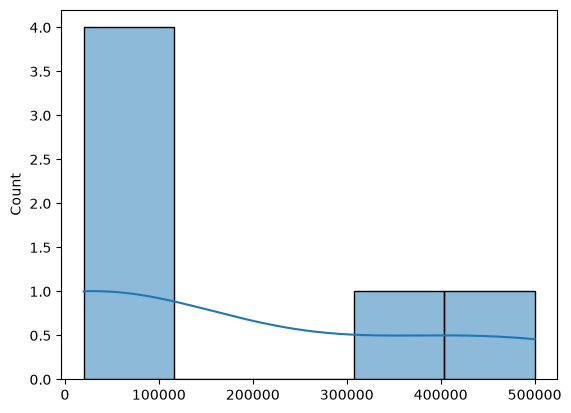

In [ ]:
# kde=True is used find the skewd line in a chart
# kde=True in sns.histplot() adds a smooth curve over the histogram.
# bins=3 → divides the data range into 3 intervals (groups) and counts how many values fall into each group.


# In the follwing code bins doesn't work..because it has a small data(like 6 values)
sns.histplot([20000,22000,25000,30000,400000,500000],kde=True)


# The following line splits like the intervals when we have more data.
# Divide the entire range of my data into 5 groups.
# 10 ───── 14.4 ───── 18.8 ───── 23.2 ───── 27.6 ───── 32
#    Bin 1       Bin 2       Bin 3       Bin 4       Bin 5
sns.histplot([20000,22000,25000,30000,400000,500000],kde=True,bins=5)

In [ ]:
# For displaying the img -->
# [📷 View Bins and KDE Explanation](Bins_KDE_Explained.png)

[📷 View Bins and KDE Explanation](Bins_KDE_Explained.png)

In [8]:
pd.DataFrame([20000,22000,25000,30000,400000,500000]).skew()

0    1.054487
dtype: float64

In [7]:
# if it skewd then transform the  data
pd.DataFrame([20000,22000,25000,30000,400000,500000]).skew()

0    1.054487
dtype: float64

In [ ]:
# if it skewd then transform the  data
pd.DataFrame(np.log1p([20000,22000,25000,30000,400000,500000])).skew()

0    0.943307
dtype: float64

##### 07-10-2026

In [9]:
df["Adm_date"]=pd.DataFrame(['2026-01-12','2026-02-02','2026-03-05'])

In [ ]:
df["Adm_date"]=pd.to_datetime(df["Adm_date"])

In [ ]:
df["Adm_date"].dtypes

# dtype('<M8[us]') means the column stores date and time values using microsecond (us) precision.

dtype('<M8[us]')

In [12]:
df['Adm_date'].dt.year

0    2026.0
1    2026.0
2    2026.0
3       NaN
4       NaN
Name: Adm_date, dtype: float64

In [13]:
df['Adm_date'].dt.month

0    1.0
1    2.0
2    3.0
3    NaN
4    NaN
Name: Adm_date, dtype: float64

In [17]:
# To find this  
# df["Average"]=df[["Python","SQL","Excel"]].mean(axis=1)

In [16]:
# To find this
# (df[["Python","SQL","Excel"]]<50).sum(axis=1)